# Introduction to Neural Networks (Notebook)


*Author: Valentina Staneva*


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1it_mt82b7f7Q8a1FgNjMEqv-7fML03ue)

[![Creative Commons License](https://i.creativecommons.org/l/by/4.0/88x31.png)](http://creativecommons.org/licenses/by/4.0/)

## Outline
- Download image dataset
- Organize data for training, validation, and testing
- Train a logistic regression as a neural network with [Keras](https://keras.io/keras_3/)
- Understand how neural network parameters are optimized
- Check performance
- Train a fully connected network with 1 hidden layer
- Compare performance

## Load libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# note we will use the Keras 3 library with a PyTorch backend
import os
os.environ["KERAS_BACKEND"] = "torch"

In [ ]:
import keras
print(keras.backend.backend())

torch


## Load the MNIST Digits dataset

In [ ]:
help(keras.datasets.mnist.load_data)

Help on function load_data in module keras.src.datasets.mnist:

load_data(path='mnist.npz')
    Loads the MNIST dataset.

    This is a dataset of 60,000 28x28 grayscale images of the 10 digits,
    along with a test set of 10,000 images.
    More info can be found at the
    [MNIST homepage](http://yann.lecun.com/exdb/mnist/).

    Args:
        path: path where to cache the dataset locally
            (relative to `~/.keras/datasets`).

    Returns:
        Tuple of NumPy arrays: `(x_train, y_train), (x_test, y_test)`.

    **`x_train`**: `uint8` NumPy array of grayscale image data with shapes
      `(60000, 28, 28)`, containing the training data. Pixel values range
      from 0 to 255.

    **`y_train`**: `uint8` NumPy array of digit labels (integers in range 0-9)
      with shape `(60000,)` for the training data.

    **`x_test`**: `uint8` NumPy array of grayscale image data with shapes
      `(10000, 28, 28)`, containing the test data. Pixel values range
      from 0 to 255.

    

## Prepare data for training

In [ ]:
# Load the data and split it between train and test sets
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255


print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")
print("x_train shape:", x_train.shape)

# convert class vectors to binary class matrices
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
print("y_train shape:", y_train.shape)

60000 train samples
10000 test samples
x_train shape: (60000, 28, 28)
y_train shape: (60000, 10)


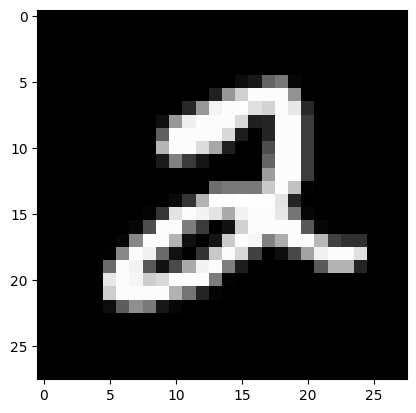

In [ ]:
# display one image
plt.imshow(x_train[5,:,:], cmap='gray')

In [ ]:
# display corresponding label (one-hot encoding format)
y_train[5,:]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
# Flatten the images: 2D -> 1D
x_train = x_train.reshape(x_train.shape[0],-1)
x_test = x_test.reshape(x_test.shape[0],-1)
print(x_test.shape, y_test.shape)

(10000, 784) (10000, 10)


## Train a Single Layer Neural Network (Logistic Regression)

We can now build and train our first fully connected neural network in Keras:

- first we define the **model** by defining layers with the right dimensions
- then we define a **loss function** we want to minimize
- then we **fit** the model on the training data

In [ ]:
from keras.layers import Input, Dense

In [ ]:
# Define a single layer neural network (no hidden units)
input_dim = x_train.shape[1]
output_dim = y_train.shape[1]

model_0 = keras.Sequential()
model_0.add(Input(shape=(input_dim,)))
model_0.add(Dense(output_dim, activation="softmax"))

📝 **Note:** We select the [softmax activation](https://en.wikipedia.org/wiki/Softmax_function) function because we have a multiclass classification problem. The softmax is a generalization of the sigmoid function which is used for binary classification problems.

In [ ]:
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

🧑‍💻 **Exercise:** Can you explain why this is the number of the trainable parameters?

In [ ]:
# Define the loss and the evaluation metrics
model_0.compile(loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
%%time
# Fit the model (this step takes ~3 min on CPU)
history_0 = model_0.fit(x_train, y_train, validation_split=0.2, epochs=15, batch_size=32)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8771 - loss: 0.4677 - val_accuracy: 0.9149 - val_loss: 0.3061
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9129 - loss: 0.3144 - val_accuracy: 0.9206 - val_loss: 0.2882
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9178 - loss: 0.2974 - val_accuracy: 0.9233 - val_loss: 0.2816
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9201 - loss: 0.2891 - val_accuracy: 0.9262 - val_loss: 0.2784
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9231 - loss: 0.2845 - val_accuracy: 0.9252 - val_loss: 0.2784
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9235 - loss: 0.2811 - val_accuracy: 0.9247 - val_loss: 0.2778
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9245 - loss: 0.2785 - val_accuracy: 0.9281 - val_loss: 0.2754
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9259 - loss: 

### Model Optimization

What happens under the hood of `.fit`?

While simple models such as linear or logistic regression can be fit with methods that use the Hessian or approximate Hessian of the loss, neural network optimization libraries are designed to work with a variety of models, hence usually do not require calculating higher-order derivatives, and are particularly suitable for optimizing loss functions over large datasets. The workhorse under the `.fit` method is the (mini-batch) Stochastic Gradient Descent.

Let's for a second, think about how minimizing a function (e.g. the loss) is the same as maximizing its negative value (e.g. the likelihood). We can hope that going in the direction of the (non-zero) gradient will get us at least to a local peak.

![](https://drive.google.com/uc?export=view&id=1AH3JCmgoFGD_3AqyG8M9SNZ29040RVtL)

**Classifier**
* $\theta$ - model parameters (weights)
* $f_{\theta}(x)$ -  neural network model as a function of parameters $\theta$ and input $x$

**Loss**
* $L_\theta (\{x_i, y_i\})$ - comparing model predictions $f_{\theta}(x_i)$ with observations $y_i$
  * Mean Squared Error for regression: $\sum_i (f_{\theta}(x_i)-y_i)^2$
  * Categorical Cross Entropy for classification: $-\sum_i \sum_c y_{ic} \log(f_{\theta}(x_i)_c)$

**Gradient Descent**

* $\theta_{t+1} = \theta_t - \alpha\nabla_\theta L_{\theta}(\underbrace{\{x_i,y_i\}}_{\textrm{all observations}})$
* $\alpha$ - learning rate (step size)
* decreases loss at each step (unless gradient is zero)
* requires calculating a gradient over the whole dataset


**Stochastic Gradient Descent**

* $\theta_{t+1} = \theta_t - \alpha\nabla_\theta L_{\theta}(\underbrace{\{x_i,y_i\}}_{\textrm{single random observation}})$

* eventually decreases loss (could be jumpy)
* cheap gradient calculation



**Mini-batch Gradient Descent**

* $\theta_{t+1} = \theta_t - \alpha\nabla_\theta L_{\theta}(\underbrace{\{x_i,y_i\}}_{\textrm{random batch of obsevations}})$

* compromise!


**Iteration:** the weights are updated based on a new batch

**Epoch:** the algorithm iterates over all batches (full training dataset)

![epochs_image](https://drive.google.com/uc?export=view&id=1Yd_l-z-PGCr7v0EwEyCWzcWBG_BoLZsX)

Image Source: [Thanapol et. al. ](https://www.mdpi.com/2076-3417/14/6/2349)

Mini-batch stochastic gradient descent is critical in being able to train huge networks on large datasets since we never have to load the whole dataset at one time! **Batch size** should allow to fit individual batch into memory and have sample big enough so weight updates and validation metrics are not too noisy.

Under certain theoretical conditions, stochastic gradient descent algorithms also converge to a critical point ([Robbins & Monroe, 1951](https://doi.org/10.1214/aoms/1177729586)), and often in practice can avoid saddles and flat regions better than gradient descent due to the added randomness.

### Evaluate the trained model



In machine learning, however, our goal is not to exactly minimize the loss on the training set (which can result in overfitting), but to achieve good performance on the validation set which hopefully translates to good performance on the test set. That is why we often monitor both the training and validation losses and stop the iterations, when the validation loss stops to improve.

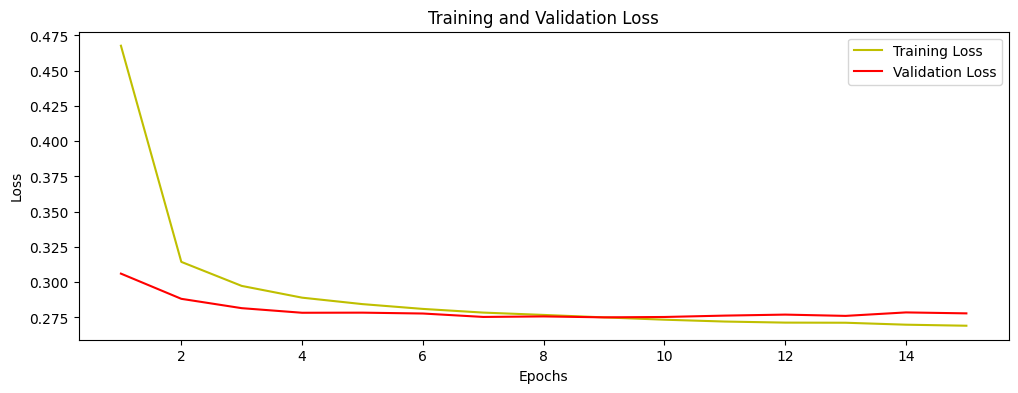

In [ ]:
# @title Training and Validation Loss
epochs = range(1, len(history_0.history["loss"]) + 1)
plt.figure(figsize=(12, 4))
plt.plot(epochs, history_0.history["loss"], 'y', label='Training Loss')
plt.plot(epochs, history_0.history["val_loss"], 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

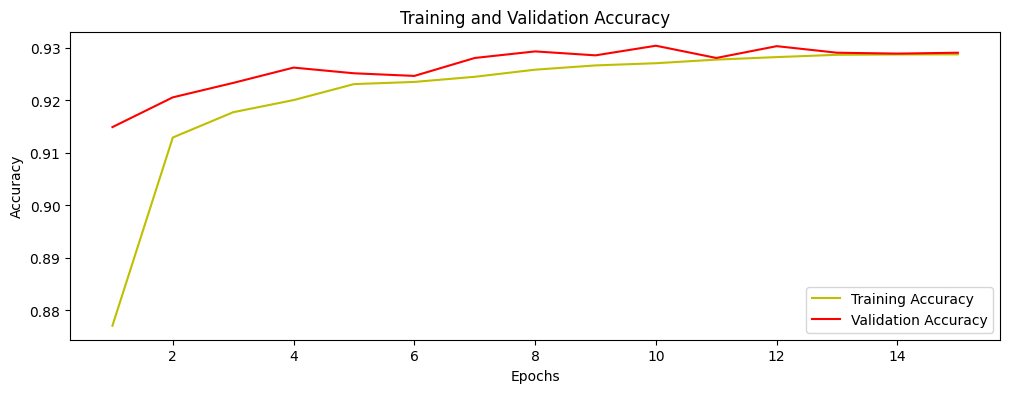

In [ ]:
# @title Training and Validation Accuracy
epochs = range(1, len(history_0.history["accuracy"]) + 1)
plt.figure(figsize=(12, 4))
plt.plot(epochs, history_0.history["accuracy"], 'y', label='Training Accuracy')
plt.plot(epochs, history_0.history["val_accuracy"], 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Train a Multilayer Neural Network

In [ ]:
# @title Define a model with 1 hidden layer of 50 units
input_dim = x_train.shape[1]
hidden_dim = 50
output_dim = y_train.shape[1]

model_1 = keras.Sequential()
model_1.add(Input(shape=(input_dim,)))
model_1.add(Dense(hidden_dim, activation="relu"))
model_1.add(Dense(output_dim, activation="softmax"))

In [ ]:
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,760 (155.31 KB)

 Trainable params: 39,760 (155.31 KB)

 Non-trainable params: 0 (0.00 B)

Note, the number of parameters is much larger than before. Can you derive this number from the network structure?

In [ ]:
# Define the loss and the evaluation metrics
model_1.compile(loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
%%time
# Fit the model (this step takes ~4 min on CPU)
history_1 = model_1.fit(x_train, y_train, validation_split=0.2, epochs=15, batch_size=32)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9033 - loss: 0.3498 - val_accuracy: 0.9440 - val_loss: 0.1989
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9491 - loss: 0.1768 - val_accuracy: 0.9555 - val_loss: 0.1561
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9611 - loss: 0.1344 - val_accuracy: 0.9628 - val_loss: 0.1328
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9675 - loss: 0.1108 - val_accuracy: 0.9635 - val_loss: 0.1255
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9720 - loss: 0.0968 - val_accuracy: 0.9653 - val_loss: 0.1208
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9752 - loss: 0.0855 - val_accuracy: 0.9665 - val_loss: 0.1189
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9769 - loss: 0.0777 - val_accuracy: 0.9690 - val_loss: 0.1135
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9793 - l

### Evaluate the trained model



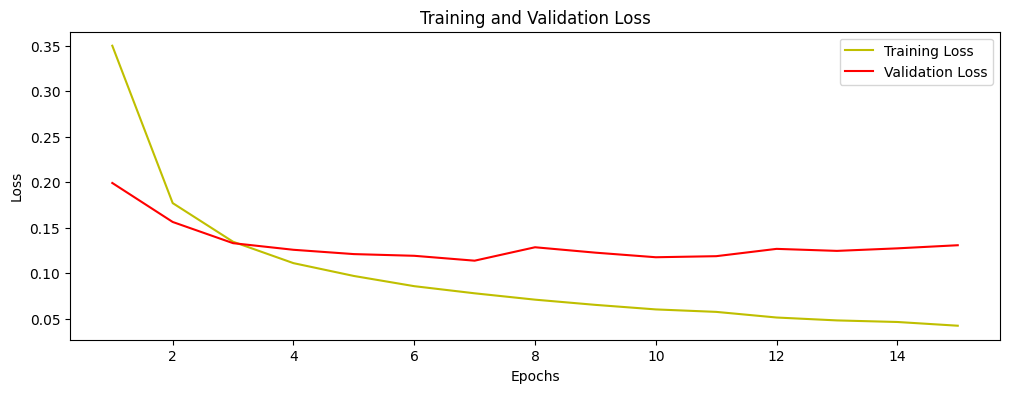

In [ ]:
# @title Training and Validation Loss
epochs = range(1, len(history_1.history["loss"]) + 1)
plt.figure(figsize=(12, 4))
plt.plot(epochs, history_1.history["loss"], 'y', label='Training Loss')
plt.plot(epochs, history_1.history["val_loss"], 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

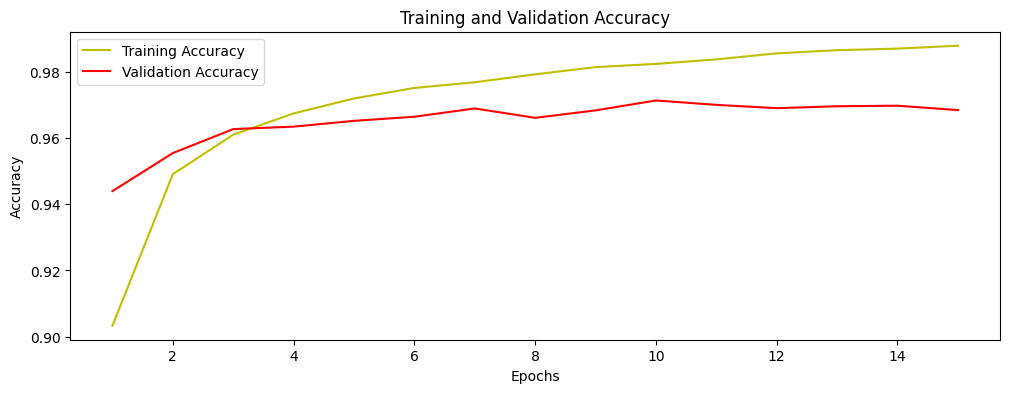

In [ ]:
# @title Training and Validation Accuracy
epochs = range(1, len(history_1.history["accuracy"]) + 1)
plt.figure(figsize=(12, 4))
plt.plot(epochs, history_1.history["accuracy"], 'y', label='Training Accuracy')
plt.plot(epochs, history_1.history["val_accuracy"], 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

🧑‍💻 **Exercise:** Add one more layer and retrain the algorithm.

In [ ]:
# Define a model with 2 hidden layers each of 50 units
input_dim = x_train.shape[1]
hidden_dim = 50
output_dim = y_train.shape[1]

model_2 = keras.Sequential()
# fill the structure of the model
# ...

In [ ]:
# Define the loss and the evaluation metrics
# ...

In [ ]:
# Fit the model
# ...

Which of the 3 models will you pick for model prediction?

## Prediction on test set

We held-out a test set which we did not touch so far, and now we want to evaluate the performance of these models on that set. This step is usually done in the end of your study after you have finished selecting parameters for your models based on the validation performance.  

⚠️ **Warning!** Ideally, this evaluation should be in a separate notebook/script, so you do not get tempted to look at the result and change the parameters. You can do that on you validation set but not on your test set.

In [ ]:
y_pred_0 = model_0.predict(x_test) # predictions for logistic regression
y_pred_1 = model_1.predict(x_test) # predictions for one hidden layer model

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

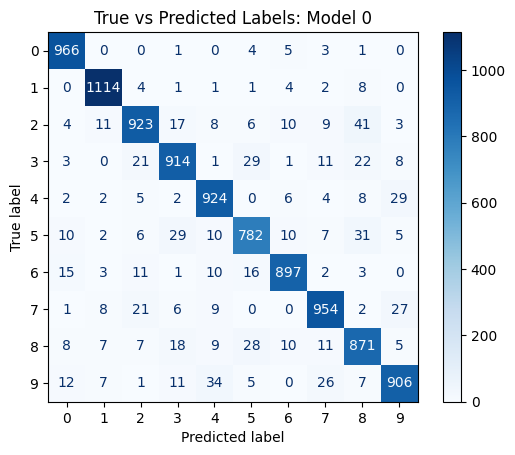

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(y_test.argmax(axis=1),
                                               y_pred_0.argmax(axis=1),
                                               display_labels=np.arange(10),
                                               # normalize='pred',
                                               cmap=plt.cm.Blues
                                               )
p = plt.title("True vs Predicted Labels: Model 0")

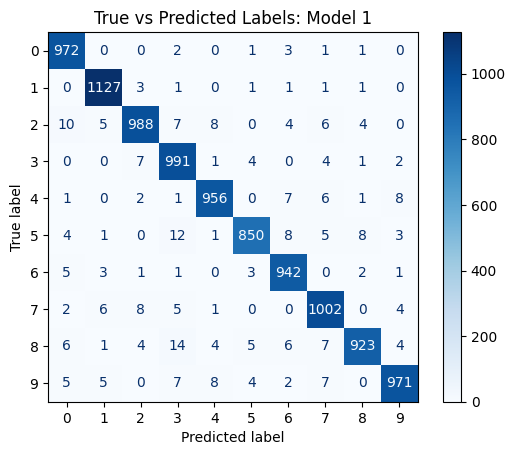

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(y_test.argmax(axis=1),
                                               y_pred_1.argmax(axis=1),
                                               display_labels=np.arange(10),
                                               # normalize='pred',
                                               cmap=plt.cm.Blues
                                               )
p = plt.title("True vs Predicted Labels: Model 1")

🧑‍💻 **Exercise:** Plot the predictions for your model.

In [ ]:
# ...

# Recap

## Conceptual Keypoints
* We first tested a simple model: logistic regression. This is our baseline! It is important to compare to a baseline.
* We held out a test set which we only used in the end.
* We compared the performance of the models on validation data.

## Technical Keypoints
* Layers in Keras can be stacked in a sequential manner.
* Activation functions can be added directly to the layer.
* The last layer needs to match the number of classes for multiclass classification problems and requires a softmax activation function (for binary classification it requires sigmoid function, and for regression a linear activation).